# Wafer Defects EDA

In this notebook we will perform exploratory data analysis (EDA) on the Wafer Defects dataset

Dataset name: WM-811K wafer map

Note:
- Make sure the dataset is downloaded from [Kaggle](https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map)
- Make sure you've installed the [required libraries](#Appendix) or ran uv sync before running this notebook

## Table of Contents                                                                                                                                          
  1. [Cleaning](#Cleaning)                                                                                                                             
  2. [Observations](#Observations)
  3. [Summary](#Summary)

In [1]:
import sys
import numpy as np
import pandas as pd # pandas==2.3.3 works for this dataset
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore', category=np.exceptions.VisibleDeprecationWarning)

from IPython.display import display, HTML
display(HTML("<style>table { margin-left: 0 !important; float: none !important; } th, td { text-align: left !important; }</style>"))

In [2]:
import kagglehub
# kagglehub.login()

path = kagglehub.dataset_download("qingyi/wm811k-wafer-map")
print(path)

/Users/purav/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1


In [3]:
print("Loading dataset...")

file_path = "/Users/purav/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1/LSWMD.pkl" # Change this to where the LSWMD.pkl is downloaded
# file_path = "./data/LSWMD.pkl"

df = pd.read_pickle(file_path)
print(f"Done. {len(df)} rows loaded.")

Loading dataset...
Done. 811457 rows loaded.


In [4]:
print(f"This dataset has {df.shape[0]} wafer samples and {df.shape[1]} features\n")
print(f"Features:")
print(df.dtypes)

This dataset has 811457 wafer samples and 6 features

Features:
waferMap           object
dieSize           float64
lotName            object
waferIndex        float64
trianTestLabel     object
failureType        object
dtype: object


In [5]:
df.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


## Cleaning

1. Rename trianTestLabel to trainTestLabel
2. Drop samples with unlabeled failureType
3. Drop samples with unlabeled trainTestLabel

This results in reduction of wafer samples to 172,950

### 1. Rename trianTestLabel to trainTestLabel

In [6]:
df = df.rename(columns={"trianTestLabel":"trainTestLabel"})

### 2. Drop samples with unlabeled failureType

There 638,507 wafer samples in this dataset that do not have a valid `failureType` label

In [7]:
# Get counts for each unique value in failureType
df["failureType_str"] = df["failureType"].astype(str)
df["failureType_str"].value_counts(dropna=False)

failureType_str
[]                 638507
[['none']]         147431
[['Edge-Ring']]      9680
[['Edge-Loc']]       5189
[['Center']]         4294
[['Loc']]            3593
[['Scratch']]        1193
[['Random']]          866
[['Donut']]           555
[['Near-full']]       149
Name: count, dtype: int64

In [8]:
# Drop samples without a failureType label
df_labeled = df[df["failureType_str"] != "[]"].copy()
df_labeled["failureType_str"].value_counts()

failureType_str
[['none']]         147431
[['Edge-Ring']]      9680
[['Edge-Loc']]       5189
[['Center']]         4294
[['Loc']]            3593
[['Scratch']]        1193
[['Random']]          866
[['Donut']]           555
[['Near-full']]       149
Name: count, dtype: int64

In [9]:
df_labeled.shape

(172950, 7)

### 3. Drop samples with unlabeled trainTestLabel

In [10]:
# Get counts for each unique value in trainTestLabel
df_labeled["trainTestLabel_str"] = df_labeled["trainTestLabel"].astype(str)
df_labeled["trainTestLabel_str"].value_counts(dropna=False)

trainTestLabel_str
[['Test']]        118595
[['Training']]     54355
Name: count, dtype: int64

In [11]:
# Drop samples without a trainTestLabel
df_cleaned = df_labeled[df_labeled["trainTestLabel_str"] != "[]"].copy()
df_cleaned["trainTestLabel_str"].value_counts()

trainTestLabel_str
[['Test']]        118595
[['Training']]     54355
Name: count, dtype: int64

In [12]:
df_cleaned[["failureType","trainTestLabel"]] = df_cleaned[["failureType_str","trainTestLabel_str"]].apply(lambda s: s.str.replace(r"[\[\]']", "", regex=True).str.strip())
df_cleaned.shape

(172950, 8)

## Observations

1. Classes are unbalanced
2. Distribution of Wafers by Lots
    - Distribution of Wafers per Lot
    - WaferIndex Distribution per Class
    - Unique failureTypes per Lot
3. Wafer Map shape distribution
    - Combined Wafer shape distribution
    - Wafer shape distribution for each class
    - Wafer shape distribution for each class
    - Die Size Distribution per Class
4. Wafer Map `failureType`
    - Defect Density per failureType
    - Average wafer map for each class
    - Wafer sampling for each class

### 1. Classes are unbalanced

- None `failureType` dominates both train and test splits
- If we exclude None, Edge Ring has dominates the rest

In [13]:
classes = ["none", "Edge-Ring", "Edge-Loc", "Center", "Loc", "Scratch", "Random", "Donut", "Near-full"]

ct = pd.crosstab(df_cleaned["trainTestLabel"], df_cleaned["failureType"])
ct

failureType,Center,Donut,Edge-Loc,Edge-Ring,Loc,Near-full,Random,Scratch,none
trainTestLabel,,,,,,,,,
Test,832,146,2772,1126,1973,95,257,693,110701
Training,3462,409,2417,8554,1620,54,609,500,36730


In [14]:
# Percentages
pd.crosstab(df_cleaned["trainTestLabel"], df_cleaned["failureType"], normalize='columns').round(2) * 100

failureType,Center,Donut,Edge-Loc,Edge-Ring,Loc,Near-full,Random,Scratch,none
trainTestLabel,,,,,,,,,
Test,19.0,26.0,53.0,12.0,55.0,64.0,30.0,58.0,75.0
Training,81.0,74.0,47.0,88.0,45.0,36.0,70.0,42.0,25.0


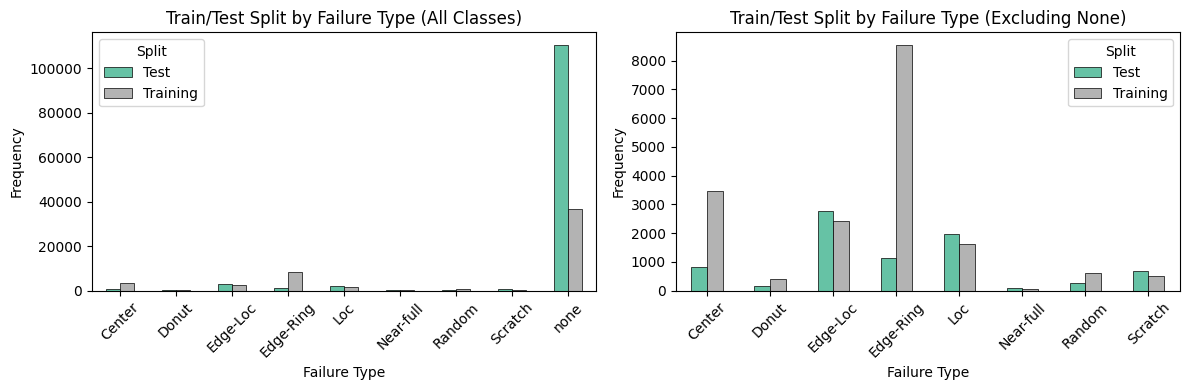

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full plot
ct.T.plot(kind='bar', stacked=False, colormap='Set2', edgecolor='black', linewidth=0.5, ax=axes[0])
axes[0].set_title("Train/Test Split by Failure Type (All Classes)")
axes[0].set_xlabel("Failure Type")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Split")

# Without 'none'
ct_no_none = ct.drop(columns='none', errors='ignore')
ct_no_none.T.plot(kind='bar', stacked=False, colormap='Set2', edgecolor='black', linewidth=0.5, ax=axes[1])
axes[1].set_title("Train/Test Split by Failure Type (Excluding None)")
axes[1].set_xlabel("Failure Type")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Split")

plt.tight_layout()
plt.show()

### 2. Distribution of Wafers by lots

- There are 10762 unique lots
- Most lots have either 25 wafers or 1 wafer
- Most lots contain 1 failureType type

In [16]:
lot_counts = df_cleaned["lotName"].value_counts()
lot_counts

lotName
lot1        25
lot43909    25
lot43923    25
lot43922    25
lot43921    25
            ..
lot33971     1
lot33988     1
lot34071     1
lot34081     1
lot18799     1
Name: count, Length: 10762, dtype: int64

#### Distribution of Wafers per Lot

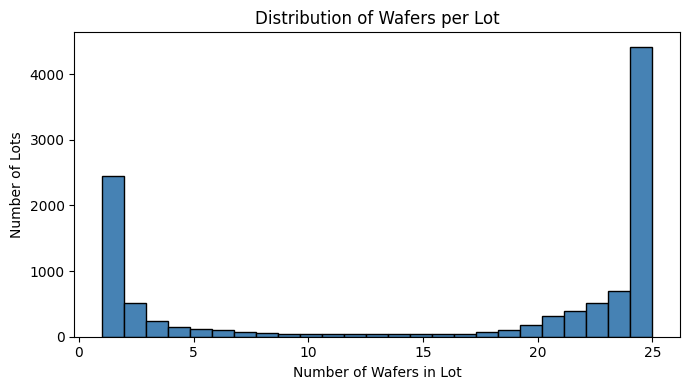

In [17]:
plt.figure(figsize=(7, 4))
plt.hist(lot_counts.values, bins=25, edgecolor='black', color='steelblue')
plt.title("Distribution of Wafers per Lot")
plt.xlabel("Number of Wafers in Lot")
plt.ylabel("Number of Lots")
plt.tight_layout()
plt.show()

#### WaferIndex Distribution per Class

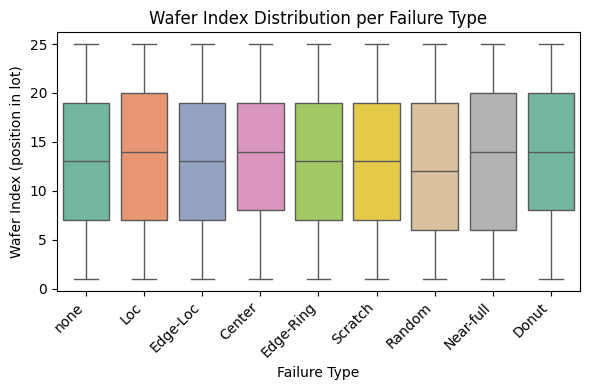

In [18]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_cleaned, x="failureType", y="waferIndex",
            hue="failureType", palette="Set2", legend=False)
plt.title("Wafer Index Distribution per Failure Type")
plt.xlabel("Failure Type")
plt.ylabel("Wafer Index (position in lot)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Unique failureTypes per Lot

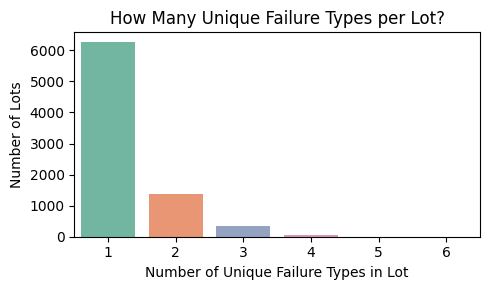

In [19]:
lot_failure_mix = (df_cleaned[df_cleaned["failureType"] != "none"]
                   .groupby("lotName")["failureType"]
                   .nunique()
                   .reset_index()
                   .rename(columns={"failureType": "unique_failure_types"}))

plt.figure(figsize=(5, 3))
sns.countplot(data=lot_failure_mix, x="unique_failure_types", hue="unique_failure_types", palette="Set2", legend=False)
plt.title("How Many Unique Failure Types per Lot?")
plt.xlabel("Number of Unique Failure Types in Lot")
plt.ylabel("Number of Lots")
plt.tight_layout()
plt.show()

### 3. Wafer Map shape distribution

- Wafers have varying sizes and shapes (Height x Width). Normalization strategy must be decided.
- Most wafers are small and square (~33×33), but a long right tail of outliers

#### Combined Wafer shape distribution

In [20]:
shapes = df_cleaned["waferMap"].map(lambda x: np.array(x).shape)

df_sizes = pd.DataFrame({
    "Height": shapes.map(lambda s: s[0]),
    "Width":  shapes.map(lambda s: s[1]),
    "Area":   shapes.map(lambda s: s[0] * s[1])
})

stats = df_sizes.describe().T
stats.insert(2, "median", df_sizes.median())
stats.insert(3, "mode",   df_sizes.mode().iloc[0])

print(stats)

           count         mean  median  mode          std   min    25%     50%  \
Height  172950.0    35.232807    33.0    25    11.096015  15.0   27.0    33.0   
Width   172950.0    34.822128    33.0    26    11.876781   3.0   27.0    33.0   
Area    172950.0  1344.812576  1020.0   675  1310.098584  45.0  676.0  1020.0   

           75%      max  
Height    41.0    212.0  
Width     40.0    204.0  
Area    1596.0  28611.0  


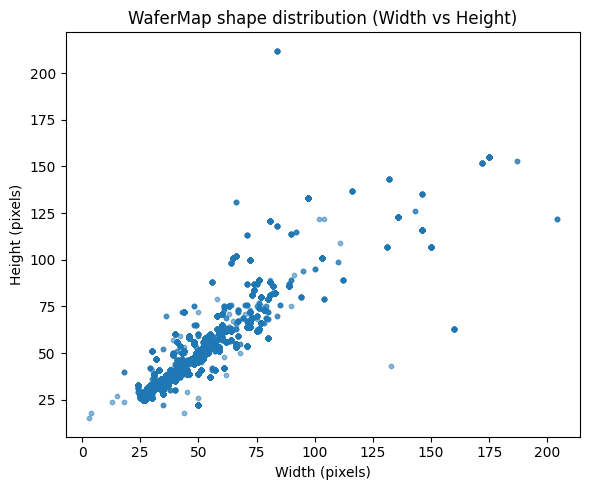

In [21]:
shapes = df_cleaned["waferMap"].map(lambda x: np.array(x).shape)
heights = shapes.map(lambda s: s[0]).to_numpy()
widths  = shapes.map(lambda s: s[1]).to_numpy()

plt.figure(figsize=(6,5))
plt.scatter(widths, heights, s=10, alpha=0.5)
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("WaferMap shape distribution (Width vs Height)")
plt.tight_layout()
plt.show()

#### Wafer shape distribution for each class

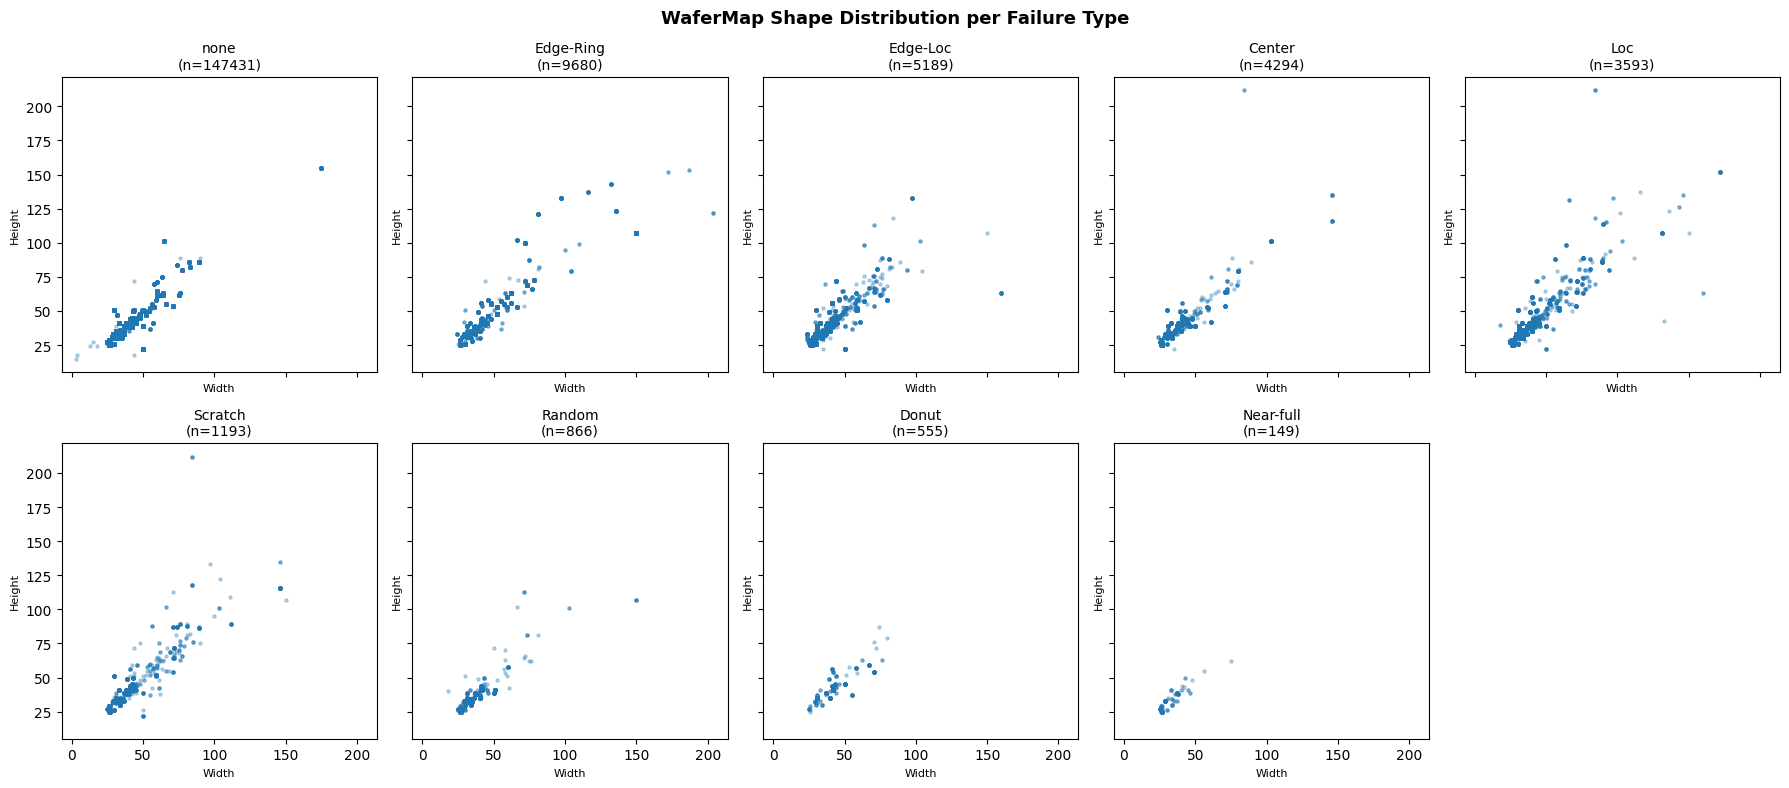

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, c in enumerate(classes):
    subset = df_cleaned[df_cleaned["failureType"] == c]
    shapes = subset["waferMap"].map(lambda x: np.array(x).shape)
    heights = shapes.map(lambda s: s[0]).to_numpy()
    widths  = shapes.map(lambda s: s[1]).to_numpy()
    
    axes[i].scatter(widths, heights, s=5, alpha=0.3)
    axes[i].set_title(f"{c}\n(n={len(subset)})", fontsize=10)
    axes[i].set_xlabel("Width", fontsize=8)
    axes[i].set_ylabel("Height", fontsize=8)

axes[-1].axis("off")
fig.suptitle("WaferMap Shape Distribution per Failure Type", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### Die Size Distribution per Class

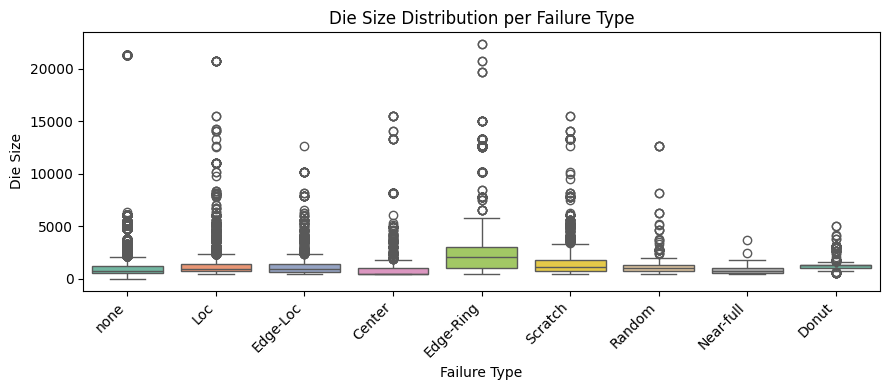

In [23]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=df_cleaned, x="failureType", y="dieSize",
            hue="failureType", palette="Set2", legend=False)
plt.title("Die Size Distribution per Failure Type")
plt.xlabel("Failure Type")
plt.ylabel("Die Size")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4. Wafer Map failureTypes

- There are 9 `failureType` classes:
    - none, Edge-Ring, Edge-Loc, Center, Loc, Scratch, Random, Donut, Near-full

#### Defect Density per failureType

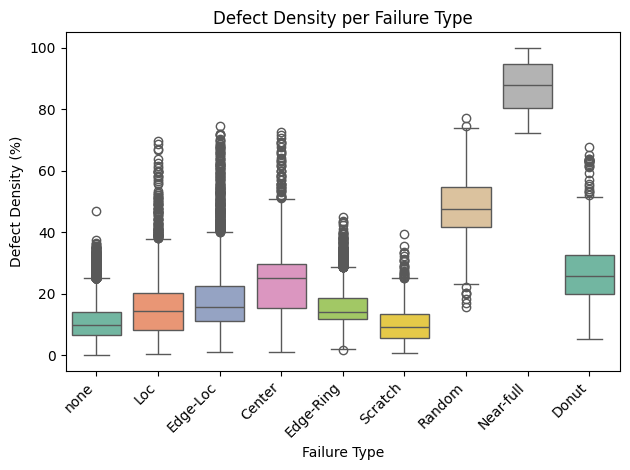

In [24]:
df_cleaned["defect_density"] = df_cleaned["waferMap"].map(
    lambda x: (np.array(x) == 2).sum() / (np.array(x) > 0).sum() * 100
)

sns.boxplot(data=df_cleaned, x="failureType", y="defect_density", hue="failureType", palette="Set2", legend=False)
plt.title("Defect Density per Failure Type")
plt.xlabel("Failure Type")
plt.ylabel("Defect Density (%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Average wafer map for each class

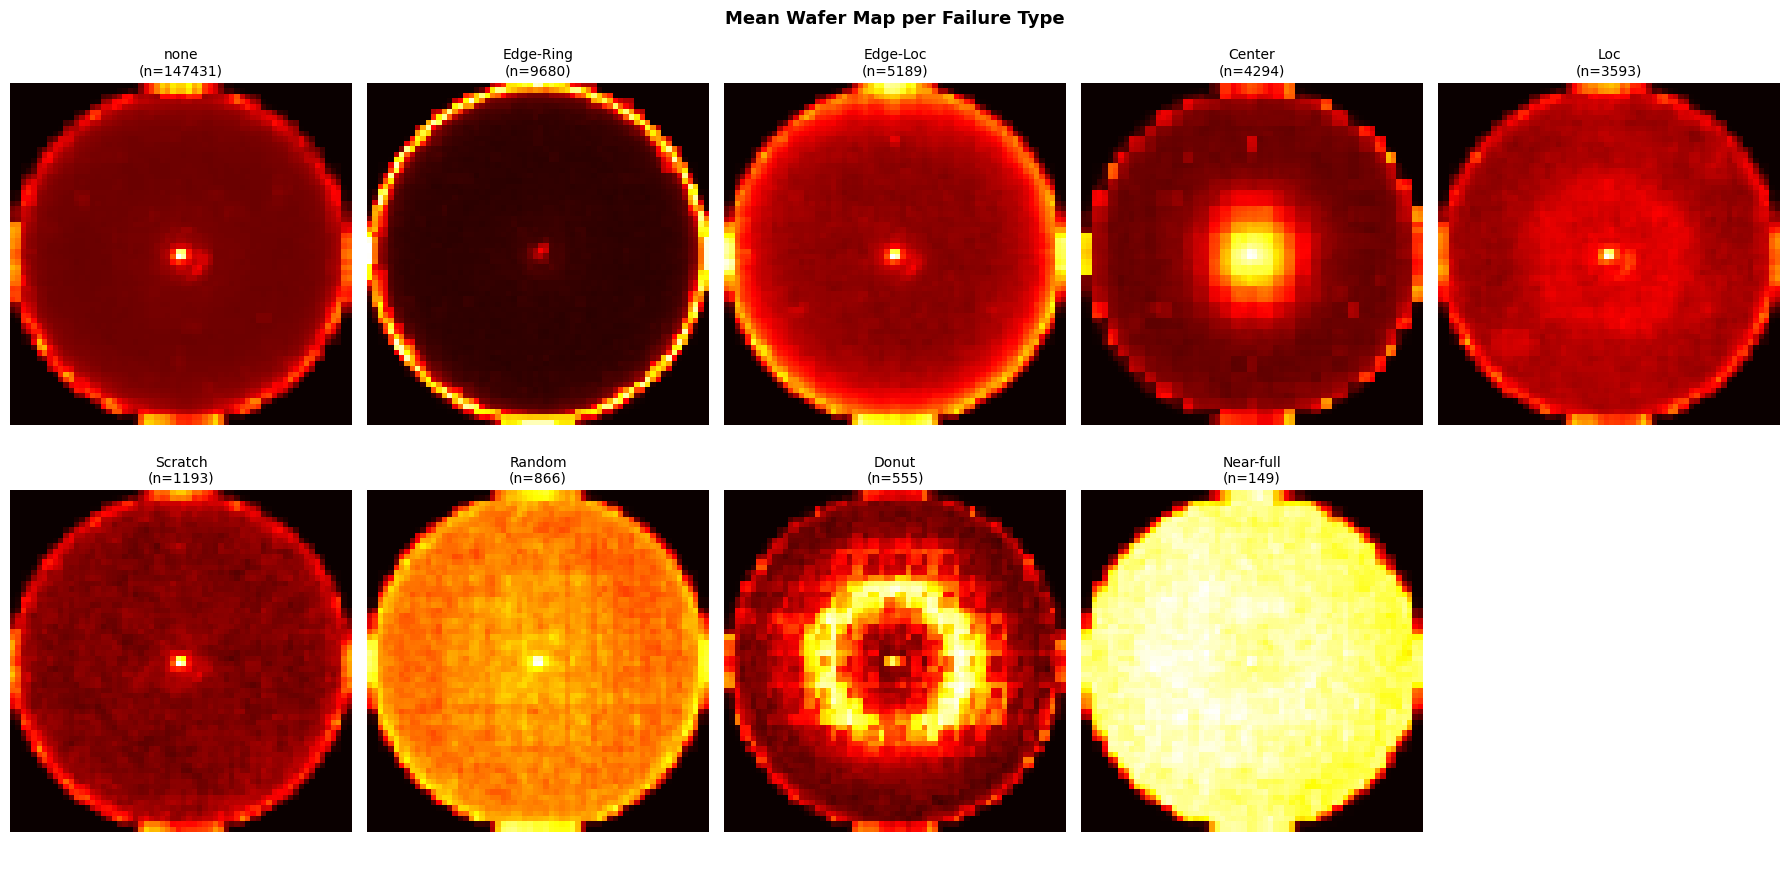

In [25]:
target = (64, 64)
def get_resized_maps(df, failure_type):
    maps = df[df["failureType"] == failure_type]["waferMap"].values
    resized = []
    for m in maps:
        m = np.array(m, dtype=np.float32)
        m[m == 1] = 0
        resized.append(np.array(Image.fromarray(m).resize(target, Image.NEAREST)))
    return np.array(resized)

fig, axes = plt.subplots(2, 5, figsize=(18, 9))
axes = axes.flatten()

for i, c in enumerate(classes):
    resized = get_resized_maps(df_cleaned, c)
    axes[i].imshow(resized.mean(axis=0), cmap="hot", interpolation="nearest")
    axes[i].set_title(f"{c}\n(n={len(resized)})", fontsize=10)
    axes[i].axis("off")

axes[-1].axis("off")
fig.suptitle("Mean Wafer Map per Failure Type", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### Wafer sampling for each class

In [26]:
def show_samples(df, failure_type, n=6, seed=0, split="both"):
    d = df[df["failureType"] == failure_type]
    if split != "both":
        d = d[d["trainTestLabel"] == split]
    d = d.sample(n=min(n, len(d)), random_state=seed)
    fig, axes = plt.subplots(1, len(d), figsize=(3*len(d), 3))
    if len(d) == 1:
        axes = [axes]
    
    for ax, (_, row) in zip(axes, d.iterrows()):
        wm = np.array(row["waferMap"])
        ax.imshow(wm, vmin=0, vmax=2, interpolation="nearest")
        ax.set_title(f'{row["failureType"]}\n({row["trainTestLabel"]})', fontsize=9)
        ax.axis("off")
    
    fig.suptitle(f'{failure_type}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

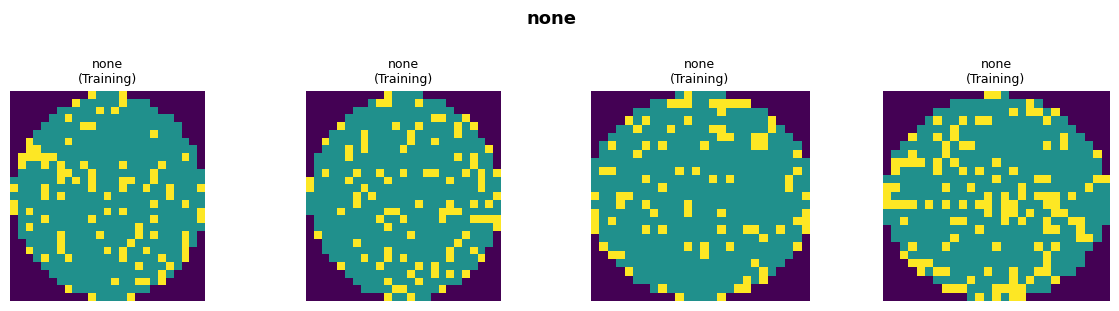

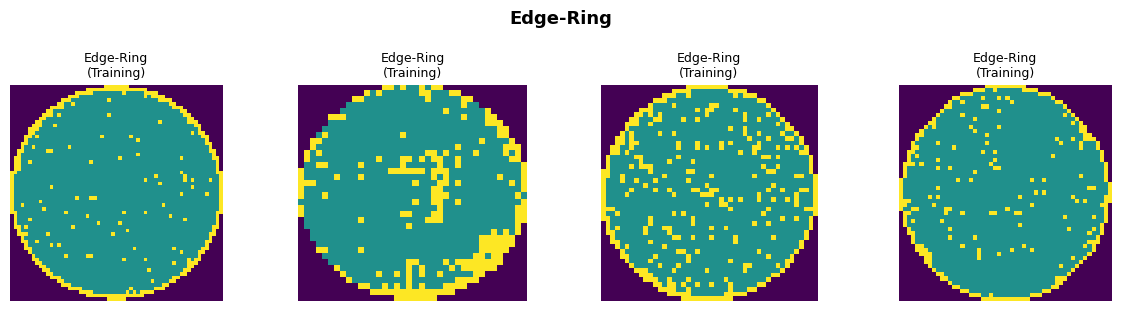

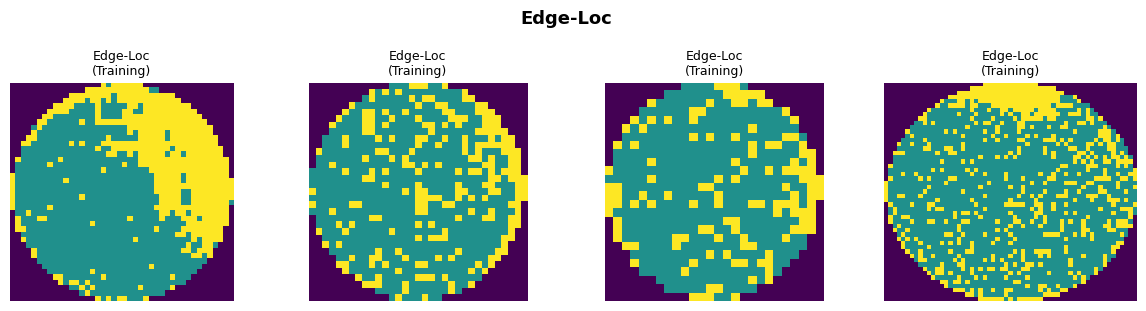

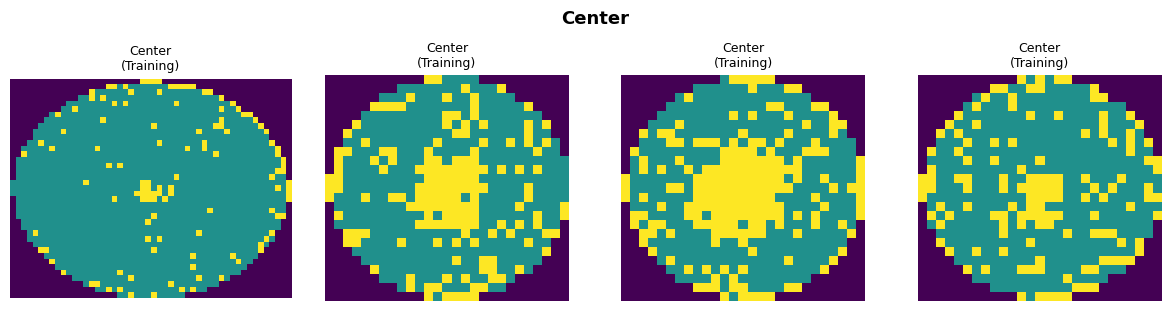

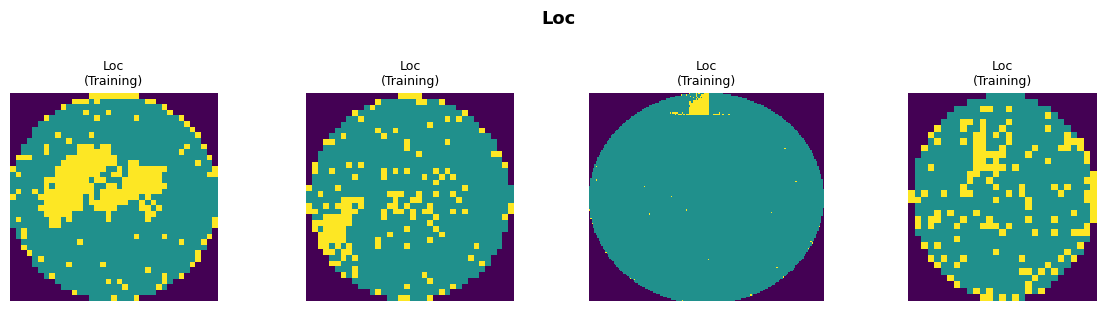

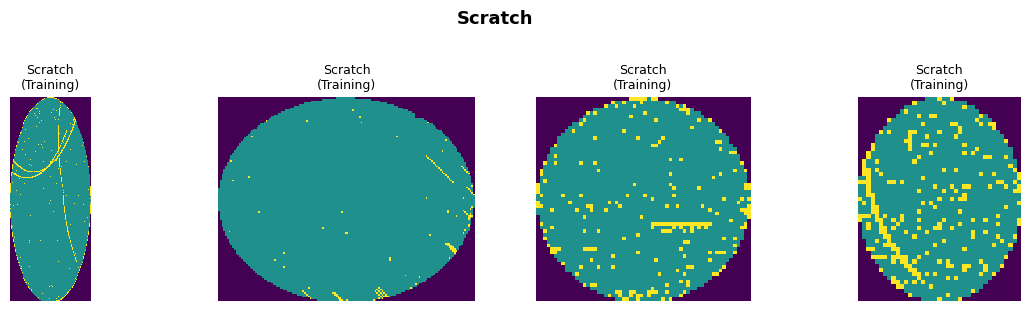

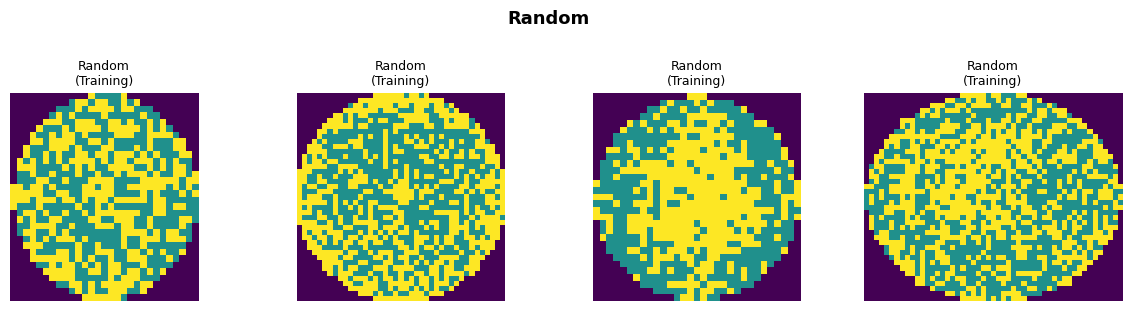

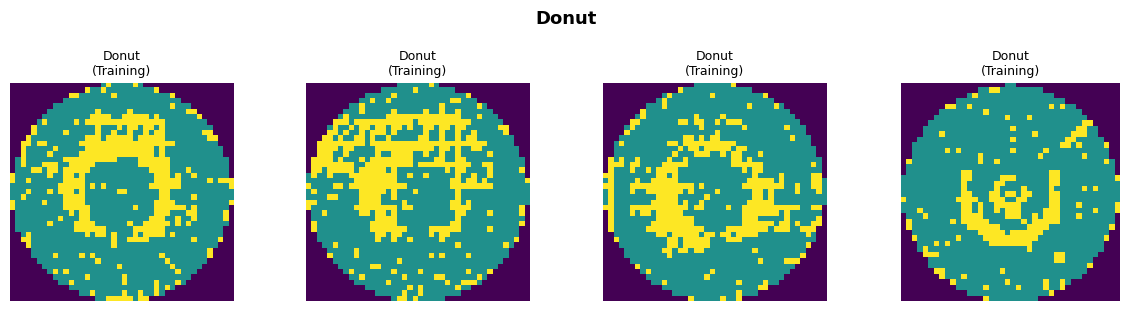

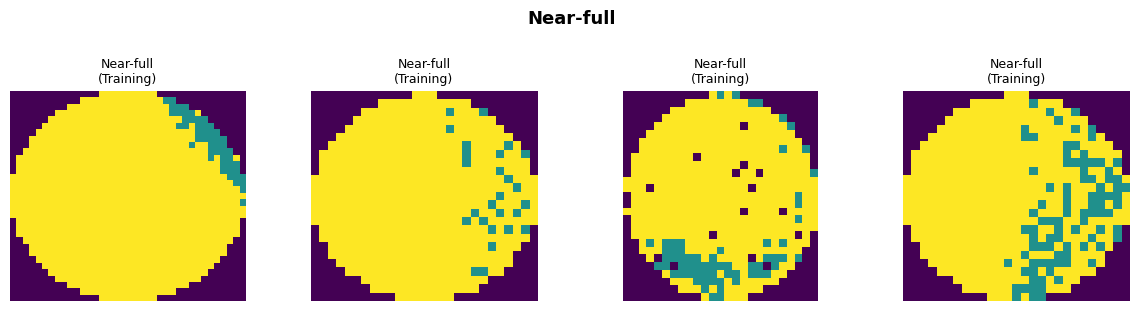

In [27]:
for c in classes:
    show_samples(df_cleaned, c, n=4, seed=0, split="Training") # adjust n to see more samples

## Summary                                                                                                                                                                                                  
### Dataset

- We are using the [WM-811K wafer map](https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map) dataset
- There are **811,457** total wafer samples, **6** features
- These features include
    - `waferMap`: 2D image with 3 pixel values (0 = outside wafer, 1 = non-defective die, 2 = defective die)
    - `dieSize`: Number of non-defective + defective dies on a wafer
    - `lotName`: Name of the lot this wafer came from
    - `waferIndex`: Position of the wafer within its lot
    - `trainTestLabel`: Is this sample part of train set or test set
    - `failureType`: Defect class label
- We dropped **638,507** samples (~79%) due to missing `failureType` label
- We ended up with **172,950** labeled samples across **9** failure types                                                                                                                 
                                                        
### Class Distribution
We have 9 output class labels:

    - none: 147,431
    - Edge-Ring: 9,680
    - Edge-Loc: 5,189
    - Center: 4,294
    - Loc: 3,593
    - Scratch: 1,193
    - Random: 866
    - Donut: 555
    - Near-full: 149

- `none` accounts for ~85% of labeled samples (severe class imbalance!)
- `Near-full` is the rarest class with only 149 samples

### Wafer Map Shape
- Wafer Maps have varying sizes
- Mean (~35x35), Median (33x33)
- 75% of samples have a height under 41 and a width under 40
### Lots
- There are **10,762** unique lots
- Most lots contain **25** wafers (full lots) or **1** wafer
- Most lots contain only **1** `failureType` type

### Train / Test Split
- Out of the remaining **172,950** samples, **54,355** (31%) are labeled as training and **118,595** are labeled as  test (69%)
- Here is how the split looks for each class:

|           | Total   | Train | Test   |
| :-------- | :------ | :---- | :----- |
| none      | 147,431 | 36730 | 110701 |
| Edge-Ring | 9,680   | 8554  | 1126   |
| Edge-Loc  | 5,189   | 2417  | 2772   |
| Center    | 4,294   | 3462  | 832    |
| Loc       | 3,593   | 1620  | 1973   |
| Scratch   | 1,193   | 500   | 693    |
| Random    | 866     | 609   | 257    |
| Donut     | 555     | 409   | 146    |
| Near-full | 149     | 54    | 95     |


### Issues to consider

1. Severe class imbalance in the dataset
    - Experiment with class weighting or augmentations to resolve this
    - Macro avg F1 for evaluation 
3. Wafer maps vary significantly in size (width × height) across samples
    - Normalization strategy will be required